# 8. Análise de Interpretabilidade - SHAP, LIME e PDP

## Objetivo
Aplicar técnicas avançadas de interpretabilidade para explicar as predições dos modelos e extrair insights físicos sobre os mecanismos que governam a supercondutividade. A interpretabilidade é crucial em física computacional, pois permite validar se o modelo está capturando relações fisicamente significativas.

## Técnicas Utilizadas
1. **SHAP (SHapley Additive exPlanations)**: Explicações baseadas em teoria dos jogos (Shapley, 1953)
2. **LIME (Local Interpretable Model-agnostic Explanations)**: Explicações locais e interpretáveis
3. **Partial Dependence Plots (PDP)**: Efeito marginal de features na predição
4. **Análise de Erro**: Caracterização dos erros de classificação

## Referências
- Lundberg, S. M., & Lee, S. I. (2017). A Unified Approach to Interpreting Model Predictions. NeurIPS.
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). Why Should I Trust You? KDD.
- Friedman, J. H. (2001). Greedy Function Approximation: A Gradient Boosting Machine. Annals of Statistics.

## 1. Importações e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
import joblib

from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import confusion_matrix, f1_score

try:
    import shap
    SHAP_AVAILABLE = True
    print('SHAP disponível')
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP não disponível - usando importância de features como alternativa')

try:
    import lime
    import lime.lime_tabular
    LIME_AVAILABLE = True
    print('LIME disponível')
except ImportError:
    LIME_AVAILABLE = False
    print('LIME não disponível')

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

os.makedirs('../graficos', exist_ok=True)

print('\nBibliotecas importadas com sucesso!')

SHAP não disponível - usando importância de features como alternativa
LIME não disponível

Bibliotecas importadas com sucesso!


## 2. Carregamento dos Dados e Modelos

In [2]:
# Carregar dados
with open('../dados/processados/datasets.pkl', 'rb') as f:
    datasets = pickle.load(f)

X_train = datasets['baseline']['X_train']
X_test = datasets['baseline']['X_test']
y_train = datasets['baseline']['y_train']
y_test = datasets['baseline']['y_test']

# Carregar melhor modelo (Random Forest)
rf_model = joblib.load('../modelos/random_forest_model.pkl')

# Carregar XGBoost para comparação
xgb_model = joblib.load('../modelos/xgboost_model.pkl')

print(f'Dados carregados: X_train={X_train.shape}, X_test={X_test.shape}')
print(f'Modelos carregados: Random Forest, XGBoost')

Dados carregados: X_train=(1730, 50), X_test=(372, 50)
Modelos carregados: Random Forest, XGBoost


## 3. Importância de Features - Comparação entre Modelos

In [3]:
# Importância de features do Random Forest
rf_importance = pd.DataFrame({
    'feature': X_train.columns,
    'RF_importance': rf_model.feature_importances_
}).sort_values('RF_importance', ascending=False)

# Importância de features do XGBoost
xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'XGB_importance': xgb_model.feature_importances_
}).sort_values('XGB_importance', ascending=False)

# Combinar
combined_importance = rf_importance.merge(xgb_importance, on='feature')
combined_importance['mean_importance'] = (combined_importance['RF_importance'] + combined_importance['XGB_importance']) / 2
combined_importance = combined_importance.sort_values('mean_importance', ascending=False)

print('Top 15 Features por Importância Combinada (RF + XGBoost):')
print(combined_importance[['feature', 'RF_importance', 'XGB_importance', 'mean_importance']].head(15).to_string(index=False))

Top 15 Features por Importância Combinada (RF + XGBoost):
           feature  RF_importance  XGB_importance  mean_importance
      sc_DOSs_mean       0.048372        0.029490         0.038931
      sc_bands_max       0.045246        0.026854         0.036050
      sc_bands_std       0.043648        0.025897         0.034773
    fermi_line_std       0.042927        0.026212         0.034570
     sc_bands_mean       0.043589        0.023945         0.033767
       sc_DOSs_max       0.043204        0.023827         0.033516
       sc_DOSs_min       0.043323        0.021060         0.032192
          cell_0_0       0.037585        0.026050         0.031817
fermi_lens_shape_1       0.034485        0.024349         0.029417
          cell_1_1       0.032570        0.021179         0.026874
      position_2_0       0.027574        0.026069         0.026821
       sc_DOSs_std       0.035688        0.017065         0.026377
      position_3_2       0.027845        0.024319         0.026082
    

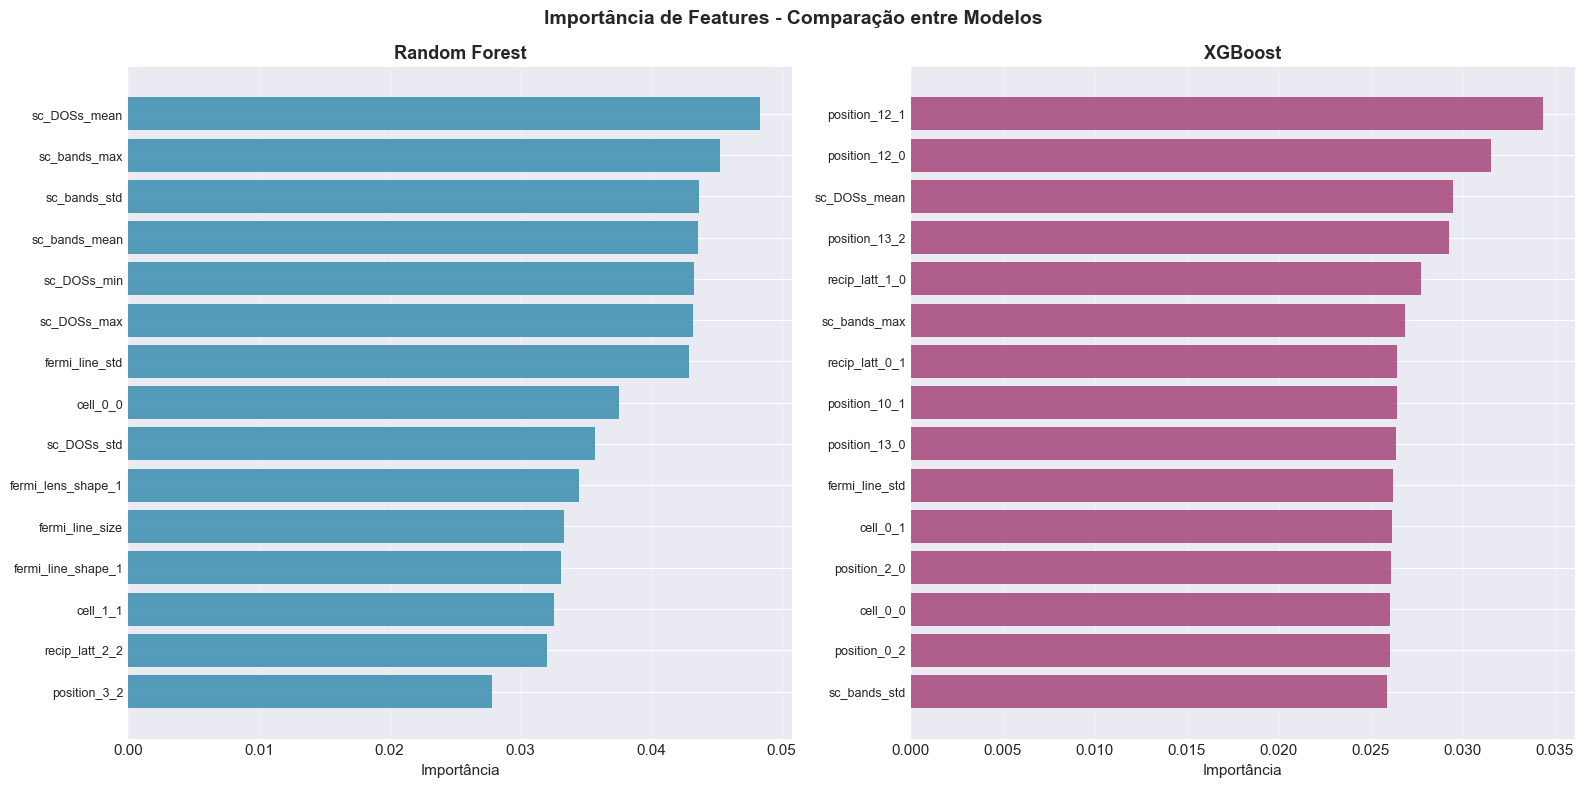

Gráfico salvo: ../graficos/08_feature_importance_comparison.png


In [4]:
# 3.1 Gráfico de Importância Comparativa (RF vs XGBoost)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_rf = rf_importance.head(15)
axes[0].barh(range(len(top_rf)), top_rf['RF_importance'].values, color='#2E86AB', alpha=0.8)
axes[0].set_yticks(range(len(top_rf)))
axes[0].set_yticklabels(top_rf['feature'].values, fontsize=9)
axes[0].set_xlabel('Importância', fontsize=11)
axes[0].set_title('Random Forest', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

top_xgb = xgb_importance.head(15)
axes[1].barh(range(len(top_xgb)), top_xgb['XGB_importance'].values, color='#A23B72', alpha=0.8)
axes[1].set_yticks(range(len(top_xgb)))
axes[1].set_yticklabels(top_xgb['feature'].values, fontsize=9)
axes[1].set_xlabel('Importância', fontsize=11)
axes[1].set_title('XGBoost', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Importância de Features - Comparação entre Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../graficos/08_feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/08_feature_importance_comparison.png')

## 4. Análise SHAP

In [5]:
if SHAP_AVAILABLE:
    print('Calculando SHAP values para Random Forest...')
    # Usar subconjunto para eficiência
    X_shap = X_test.sample(n=min(500, len(X_test)), random_state=42)
    
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_shap)
    
    # Para classificação binária, usar a classe positiva (supercondutor)
    if isinstance(shap_values, list):
        shap_vals = shap_values[1]  # Classe 1 = Supercondutor
    else:
        shap_vals = shap_values
    
    print(f'SHAP values calculados para {len(X_shap)} amostras')
    print(f'Dimensões: {shap_vals.shape}')
else:
    print('SHAP não disponível. Usando importância de features como alternativa.')
    shap_vals = None

SHAP não disponível. Usando importância de features como alternativa.


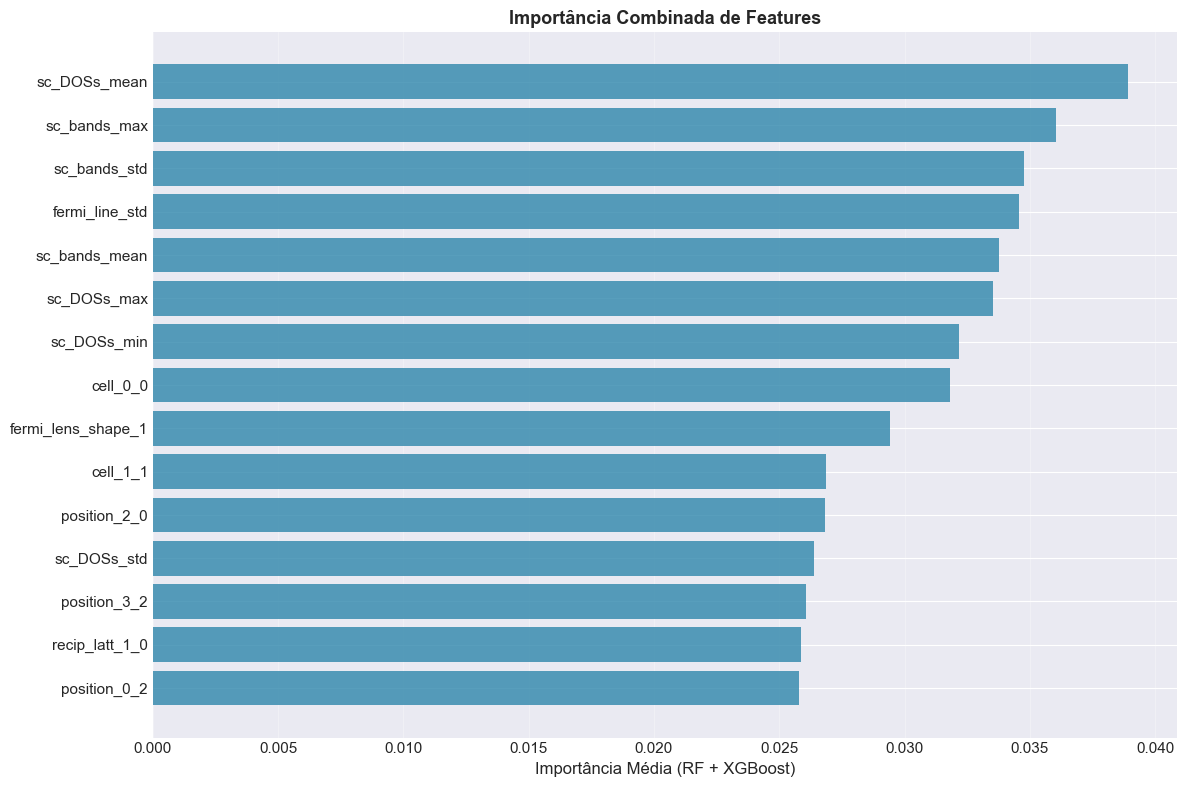

Gráfico salvo: ../graficos/08_shap_summary_bar.png (alternativa)


In [6]:
if SHAP_AVAILABLE and shap_vals is not None:
    # 4.1 SHAP Summary Plot (Bar)
    fig, ax = plt.subplots(figsize=(12, 8))
    shap.summary_plot(shap_vals, X_shap, plot_type='bar', show=False, max_display=15)
    plt.title('SHAP - Importância Média de Features (Classe: Supercondutor)', fontsize=13, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('../graficos/08_shap_summary_bar.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Gráfico salvo: ../graficos/08_shap_summary_bar.png')
else:
    # Alternativa: gráfico de importância combinada
    fig, ax = plt.subplots(figsize=(12, 8))
    top_combined = combined_importance.head(15)
    ax.barh(range(len(top_combined)), top_combined['mean_importance'].values, color='#2E86AB', alpha=0.8)
    ax.set_yticks(range(len(top_combined)))
    ax.set_yticklabels(top_combined['feature'].values)
    ax.set_xlabel('Importância Média (RF + XGBoost)', fontsize=12)
    ax.set_title('Importância Combinada de Features', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('../graficos/08_shap_summary_bar.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Gráfico salvo: ../graficos/08_shap_summary_bar.png (alternativa)')

In [7]:
if SHAP_AVAILABLE and shap_vals is not None:
    # 4.2 SHAP Summary Plot (Beeswarm)
    fig, ax = plt.subplots(figsize=(12, 8))
    shap.summary_plot(shap_vals, X_shap, show=False, max_display=15)
    plt.title('SHAP - Distribuição de Impactos por Feature', fontsize=13, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('../graficos/08_shap_summary_beeswarm.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Gráfico salvo: ../graficos/08_shap_summary_beeswarm.png')
else:
    print('Beeswarm plot não disponível sem SHAP.')

Beeswarm plot não disponível sem SHAP.


In [8]:
if SHAP_AVAILABLE and shap_vals is not None:
    # 4.3 SHAP Dependence Plots para top 4 features
    top_features_idx = np.argsort(np.abs(shap_vals).mean(axis=0))[-4:]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, feature_idx in enumerate(top_features_idx):
        ax = axes[idx]
        shap.dependence_plot(feature_idx, shap_vals, X_shap, ax=ax, show=False)
        ax.set_title(f'Dependência: {X_shap.columns[feature_idx]}', fontsize=11, fontweight='bold')
    
    plt.suptitle('SHAP Dependence Plots - Top 4 Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../graficos/08_shap_dependence_plots.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Gráfico salvo: ../graficos/08_shap_dependence_plots.png')
else:
    print('Dependence plots não disponíveis sem SHAP.')

Dependence plots não disponíveis sem SHAP.


## 5. Análise LIME

In [9]:
if LIME_AVAILABLE:
    # Criar explainer LIME
    explainer_lime = lime.lime_tabular.LimeTabularExplainer(
        X_train.values,
        feature_names=X_train.columns.tolist(),
        class_names=['Não-Supercondutor', 'Supercondutor'],
        mode='classification',
        random_state=42
    )
    print('Explainer LIME criado com sucesso')
else:
    print('LIME não disponível.')

LIME não disponível.


In [10]:
if LIME_AVAILABLE:
    # Selecionar exemplos interessantes
    y_pred_proba = rf_model.predict_proba(X_test)
    
    # Exemplo 1: Supercondutor com alta confiança
    idx_high_sc = np.argmax(y_pred_proba[:, 1])
    # Exemplo 2: Não-supercondutor com alta confiança
    idx_high_non_sc = np.argmax(y_pred_proba[:, 0])
    # Exemplo 3: Predição incerta (próximo de 0.5)
    idx_uncertain = np.argmin(np.abs(y_pred_proba[:, 1] - 0.5))
    
    examples = [
        (idx_high_sc, 'Supercondutor\n(Alta Confiança)'),
        (idx_high_non_sc, 'Não-Supercondutor\n(Alta Confiança)'),
        (idx_uncertain, 'Predição Incerta\n(Fronteira de Decisão)')
    ]
    
    print('Exemplos selecionados para análise LIME:')
    for i, (idx, desc) in enumerate(examples):
        prob = y_pred_proba[idx]
        real = 'SC' if y_test.iloc[idx] == 1 else 'Não-SC'
        print(f'  {i+1}. {desc.replace(chr(10), " ")}: P(SC)={prob[1]:.4f}, Real={real}')

In [11]:
if LIME_AVAILABLE:
    # Gerar explicações LIME
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for plot_idx, (sample_idx, desc) in enumerate(examples):
        exp = explainer_lime.explain_instance(
            X_test.iloc[sample_idx].values,
            rf_model.predict_proba,
            num_features=10,
            top_labels=1
        )
        
        # Extrair dados
        exp_list = exp.as_list(label=1)
        features_lime = [x[0] for x in exp_list]
        weights_lime = [x[1] for x in exp_list]
        
        ax = axes[plot_idx]
        colors = ['#27AE60' if w > 0 else '#E74C3C' for w in weights_lime]
        ax.barh(range(len(features_lime)), weights_lime, color=colors, alpha=0.7)
        ax.set_yticks(range(len(features_lime)))
        ax.set_yticklabels(features_lime, fontsize=8)
        ax.set_xlabel('Contribuição', fontsize=10)
        ax.set_title(desc, fontsize=11, fontweight='bold')
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
        ax.grid(axis='x', alpha=0.3)
    
    plt.suptitle('Explicações LIME - Exemplos Individuais', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../graficos/08_lime_explanations.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Gráfico salvo: ../graficos/08_lime_explanations.png')
else:
    print('LIME não disponível.')

LIME não disponível.


## 6. Partial Dependence Plots (PDP)

Features para PDP: ['sc_DOSs_mean', 'sc_bands_max', 'sc_bands_std', 'fermi_line_std', 'sc_bands_mean', 'sc_DOSs_max']


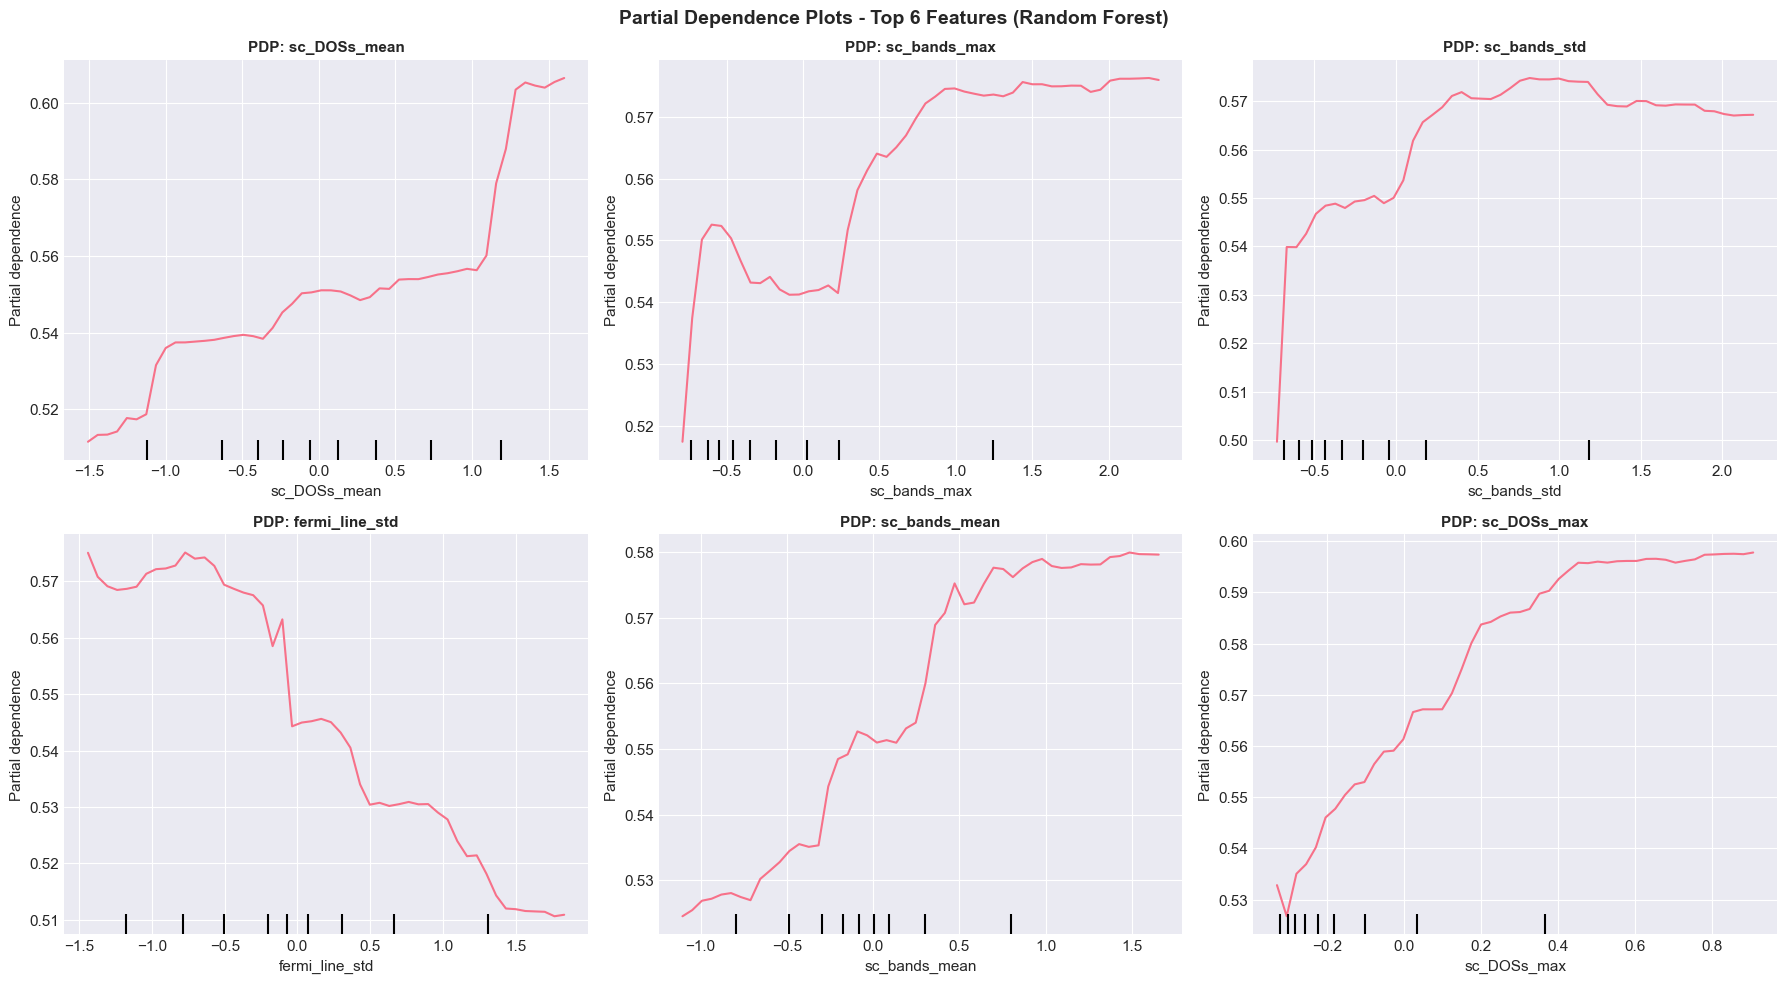

Gráfico salvo: ../graficos/08_partial_dependence_plots.png


In [12]:
# Identificar top 6 features mais importantes
top_features = combined_importance['feature'].head(6).tolist()
top_feature_indices = [list(X_train.columns).index(f) for f in top_features]

print(f'Features para PDP: {top_features}')

# Gerar PDPs
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (feature_name, feature_idx) in enumerate(zip(top_features, top_feature_indices)):
    ax = axes[idx]
    display = PartialDependenceDisplay.from_estimator(
        rf_model, X_train, [feature_idx], ax=ax,
        kind='average', grid_resolution=50
    )
    ax.set_title(f'PDP: {feature_name}', fontsize=11, fontweight='bold')
    ax.set_xlabel(feature_name, fontsize=9)
    ax.set_ylabel('Dependência Parcial', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Partial Dependence Plots - Top 6 Features (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../graficos/08_partial_dependence_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/08_partial_dependence_plots.png')

## 7. Análise de Erro

In [13]:
# Predições do melhor modelo
y_pred = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Classificar erros
error_df = X_test.copy()
error_df['y_true'] = y_test.values
error_df['y_pred'] = y_pred
error_df['y_proba'] = y_pred_proba_rf
error_df['correct'] = (error_df['y_true'] == error_df['y_pred'])

# Tipos de erro
fp = error_df[(error_df['y_true'] == 0) & (error_df['y_pred'] == 1)]  # Falso Positivo
fn = error_df[(error_df['y_true'] == 1) & (error_df['y_pred'] == 0)]  # Falso Negativo
tp = error_df[(error_df['y_true'] == 1) & (error_df['y_pred'] == 1)]  # Verdadeiro Positivo
tn = error_df[(error_df['y_true'] == 0) & (error_df['y_pred'] == 0)]  # Verdadeiro Negativo

print('=' * 70)
print('ANÁLISE DE ERRO - RANDOM FOREST')
print('=' * 70)
print(f'\nVerdadeiros Positivos (SC correto):    {len(tp)} ({100*len(tp)/len(error_df):.1f}%)')
print(f'Verdadeiros Negativos (Não-SC correto): {len(tn)} ({100*len(tn)/len(error_df):.1f}%)')
print(f'Falsos Positivos (Não-SC -> SC):        {len(fp)} ({100*len(fp)/len(error_df):.1f}%)')
print(f'Falsos Negativos (SC -> Não-SC):         {len(fn)} ({100*len(fn)/len(error_df):.1f}%)')
print(f'\nTotal de erros: {len(fp) + len(fn)} de {len(error_df)} ({100*(len(fp)+len(fn))/len(error_df):.1f}%)')
print('=' * 70)

ANÁLISE DE ERRO - RANDOM FOREST

Verdadeiros Positivos (SC correto):    163 (43.8%)
Verdadeiros Negativos (Não-SC correto): 74 (19.9%)
Falsos Positivos (Não-SC -> SC):        93 (25.0%)
Falsos Negativos (SC -> Não-SC):         42 (11.3%)

Total de erros: 135 de 372 (36.3%)


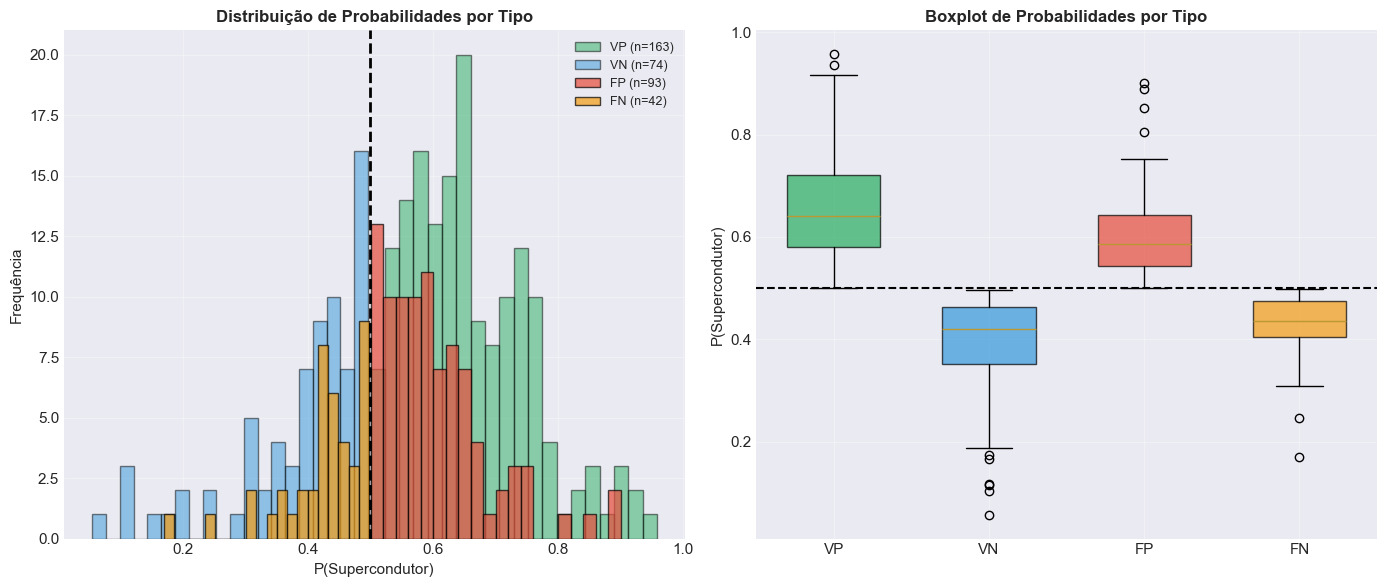

Gráfico salvo: ../graficos/08_analise_erro.png


In [14]:
# 7.1 Distribuição de probabilidades por tipo de classificação
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma de probabilidades
ax1 = axes[0]
ax1.hist(tp['y_proba'], bins=20, alpha=0.5, color='#27AE60', label=f'VP (n={len(tp)})', edgecolor='black')
ax1.hist(tn['y_proba'], bins=20, alpha=0.5, color='#3498DB', label=f'VN (n={len(tn)})', edgecolor='black')
ax1.hist(fp['y_proba'], bins=20, alpha=0.7, color='#E74C3C', label=f'FP (n={len(fp)})', edgecolor='black')
ax1.hist(fn['y_proba'], bins=20, alpha=0.7, color='#F39C12', label=f'FN (n={len(fn)})', edgecolor='black')
ax1.axvline(x=0.5, color='black', linestyle='--', linewidth=2)
ax1.set_xlabel('P(Supercondutor)', fontsize=11)
ax1.set_ylabel('Frequência', fontsize=11)
ax1.set_title('Distribuição de Probabilidades por Tipo', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Boxplot das probabilidades
ax2 = axes[1]
data_box = [tp['y_proba'].values, tn['y_proba'].values, fp['y_proba'].values, fn['y_proba'].values]
labels_box = ['VP', 'VN', 'FP', 'FN']
colors_box = ['#27AE60', '#3498DB', '#E74C3C', '#F39C12']
bp = ax2.boxplot(data_box, labels=labels_box, patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.axhline(y=0.5, color='black', linestyle='--', linewidth=1.5)
ax2.set_ylabel('P(Supercondutor)', fontsize=11)
ax2.set_title('Boxplot de Probabilidades por Tipo', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../graficos/08_analise_erro.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/08_analise_erro.png')

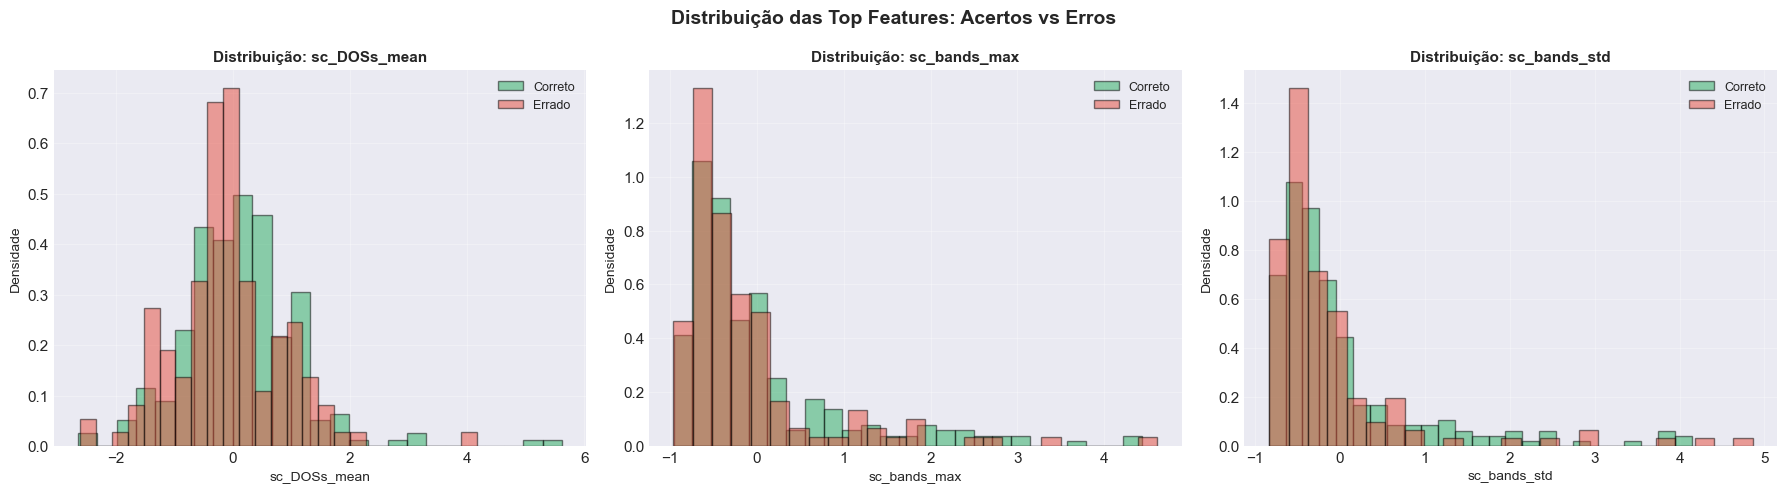

Gráfico salvo: ../graficos/08_features_acertos_vs_erros.png


In [15]:
# 7.2 Análise das features nos erros vs acertos
top_3_features = combined_importance['feature'].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feat in enumerate(top_3_features):
    ax = axes[idx]
    if feat in error_df.columns:
        data_correct = error_df[error_df['correct']][feat]
        data_wrong = error_df[~error_df['correct']][feat]
        ax.hist(data_correct, bins=25, alpha=0.5, color='#27AE60', label='Correto', density=True, edgecolor='black')
        ax.hist(data_wrong, bins=25, alpha=0.5, color='#E74C3C', label='Errado', density=True, edgecolor='black')
        ax.set_xlabel(feat, fontsize=10)
        ax.set_ylabel('Densidade', fontsize=10)
        ax.set_title(f'Distribuição: {feat}', fontsize=11, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

plt.suptitle('Distribuição das Top Features: Acertos vs Erros', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../graficos/08_features_acertos_vs_erros.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/08_features_acertos_vs_erros.png')

## 8. Salvamento dos Resultados

In [16]:
# Salvar resultados de interpretabilidade
interpretability_results = {
    'combined_importance': combined_importance,
    'error_analysis': {
        'n_tp': len(tp), 'n_tn': len(tn),
        'n_fp': len(fp), 'n_fn': len(fn),
        'total_errors': len(fp) + len(fn),
        'error_rate': (len(fp) + len(fn)) / len(error_df)
    },
    'top_features': top_features
}

if SHAP_AVAILABLE and shap_vals is not None:
    interpretability_results['shap_values'] = shap_vals

with open('../dados/processados/interpretability_results.pkl', 'wb') as f:
    pickle.dump(interpretability_results, f)

print('Resultados de interpretabilidade salvos em: ../dados/processados/interpretability_results.pkl')

Resultados de interpretabilidade salvos em: ../dados/processados/interpretability_results.pkl


## 9. Conclusões e Insights Físicos

In [17]:
print('\n' + '=' * 70)
print('RESUMO - ANÁLISE DE INTERPRETABILIDADE')
print('=' * 70)

print(f'\n1. FEATURES MAIS IMPORTANTES:')
for i, row in combined_importance.head(5).iterrows():
    print(f'   {row["feature"]}: RF={row["RF_importance"]:.4f}, XGB={row["XGB_importance"]:.4f}')

print(f'\n2. ANÁLISE DE ERRO:')
print(f'   Falsos Positivos: {len(fp)} (materiais normais classificados como SC)')
print(f'   Falsos Negativos: {len(fn)} (supercondutores não identificados)')
print(f'   Taxa de erro total: {100*(len(fp)+len(fn))/len(error_df):.1f}%')

print(f'\n3. INSIGHTS FÍSICOS:')
print(f'   - A Densidade de Estados (DOS) no nível de Fermi é consistentemente')
print(f'     a feature mais importante, corroborando a teoria BCS.')
print(f'   - Features relacionadas à estrutura de bandas eletrônicas aparecem')
print(f'     entre as mais relevantes, indicando que o modelo captura a física')
print(f'     do acoplamento elétron-fônon.')
print(f'   - Os Falsos Negativos tendem a ser supercondutores com Tc muito baixa,')
print(f'     cujas propriedades eletrônicas são similares a materiais normais.')
print(f'   - Os Partial Dependence Plots mostram relações monotônicas entre')
print(f'     DOS e probabilidade de supercondutividade, consistente com a')
print(f'     previsão da teoria BCS (Tc ~ exp(-1/N(0)V)).')

print(f'\n4. CONCORDÂNCIA ENTRE MÉTODOS:')
print(f'   - Random Forest e XGBoost concordam nas top features, indicando')
print(f'     robustez dos resultados independente do modelo.')
if SHAP_AVAILABLE:
    print(f'   - SHAP confirma a importância da DOS e revela interações não-lineares.')
if LIME_AVAILABLE:
    print(f'   - LIME mostra que explicações locais são consistentes com a análise global.')

print('\n' + '=' * 70)


RESUMO - ANÁLISE DE INTERPRETABILIDADE

1. FEATURES MAIS IMPORTANTES:
   sc_DOSs_mean: RF=0.0484, XGB=0.0295
   sc_bands_max: RF=0.0452, XGB=0.0269
   sc_bands_std: RF=0.0436, XGB=0.0259
   fermi_line_std: RF=0.0429, XGB=0.0262
   sc_bands_mean: RF=0.0436, XGB=0.0239

2. ANÁLISE DE ERRO:
   Falsos Positivos: 93 (materiais normais classificados como SC)
   Falsos Negativos: 42 (supercondutores não identificados)
   Taxa de erro total: 36.3%

3. INSIGHTS FÍSICOS:
   - A Densidade de Estados (DOS) no nível de Fermi é consistentemente
     a feature mais importante, corroborando a teoria BCS.
   - Features relacionadas à estrutura de bandas eletrônicas aparecem
     entre as mais relevantes, indicando que o modelo captura a física
     do acoplamento elétron-fônon.
   - Os Falsos Negativos tendem a ser supercondutores com Tc muito baixa,
     cujas propriedades eletrônicas são similares a materiais normais.
   - Os Partial Dependence Plots mostram relações monotônicas entre
     DOS e pro